In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import autoslo.utils.paths as pu
import os

granularity = 'hourly'
dir = os.path.join(pu.get_data_path(), 'redset_byproducts', 'provisioned', f'{granularity}_splits')

dfs = {
    split: pd.read_parquet(os.path.join(dir, f'{split}_{granularity}.parquet'))
    for split in ['train', 'validation', 'test']
}

for split, df in dfs.items():
    df = df[df["unique_cluster_size_count"] == 1].copy()
    df.loc[:, "cluster_size"] = df["unique_cluster_sizes"].apply(
        lambda x: x[0]
    )
    df.loc[:, "rpu"] = df["cluster_size"] * 8
    dfs[split] = df

In [17]:
dfs['train'].columns

Index(['hour_bin', 'instance_id', 'num_queries', 'interarrival_time_s_mean',
       'interarrival_time_s_p5', 'interarrival_time_s_p1',
       'unique_cluster_sizes', 'unique_cluster_size_count',
       'nan_cluster_size_num_queries', 'duration_s_p95', 'duration_s_p99',
       'duration_s_sum', 'was_aborted_mean', 'was_cached_mean',
       'num_permanent_tables_accessed_mean',
       'num_external_tables_accessed_mean', 'num_system_tables_accessed_mean',
       'mbytes_scanned_mean', 'mbytes_scanned_p95', 'mbytes_scanned_p99',
       'mbytes_spilled_mean', 'mbytes_spilled_p95', 'mbytes_spilled_p99',
       'num_joins_mean', 'num_joins_p95', 'num_joins_p99', 'num_scans_mean',
       'num_scans_p95', 'num_scans_p99', 'num_aggregations_mean',
       'num_aggregations_p95', 'num_aggregations_p99',
       'nan_cluster_size_duration_s_sum', 'query_type_analyze',
       'query_type_copy', 'query_type_ctas', 'query_type_delete',
       'query_type_insert', 'query_type_other', 'query_type_selec

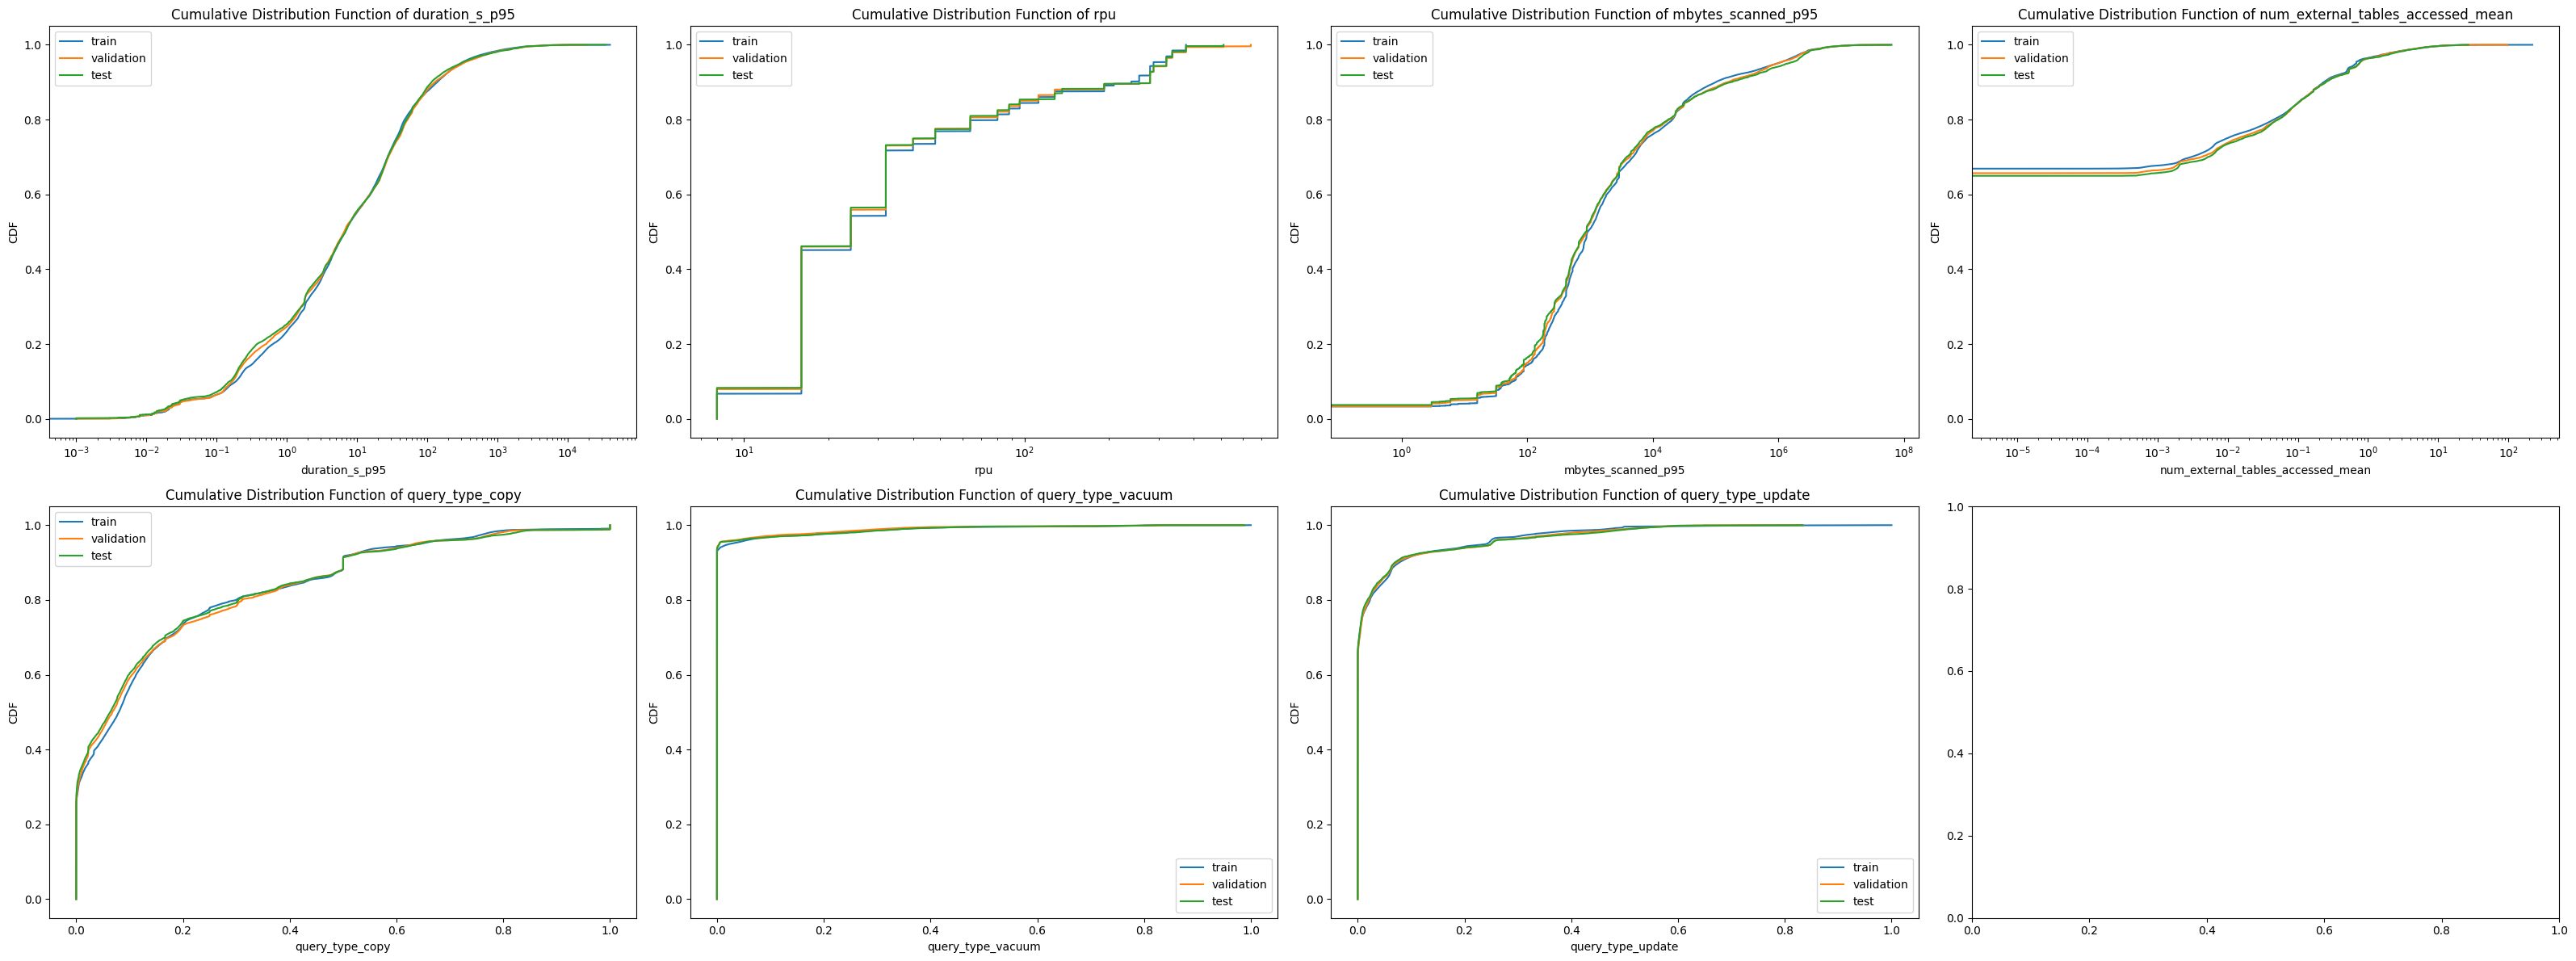

In [25]:
# For each column specified below, create a subplot of its cdf across the three splits
columns_to_plot = {
    'duration_s_p95': 'log', 
    'rpu': 'log',
    'mbytes_scanned_p95': 'log',
    'num_external_tables_accessed_mean': 'log',
    'query_type_copy': 'linear',
    'query_type_vacuum': 'linear',
    'query_type_update': 'linear',
}
ncols = min(4, len(columns_to_plot))
nrows = (len(columns_to_plot) + ncols - 1) // ncols

fig, axs = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6 * nrows), squeeze=False)
for i, column in enumerate(columns_to_plot.keys()):
    ax = axs[i // ncols, i % ncols] if len(columns_to_plot) > 1 else axs
    for split, df in dfs.items():
        sorted_values = df[column].sort_values()
        cdf = pd.Series(range(1, len(sorted_values) + 1)) / len(sorted_values)
        ax.plot(sorted_values, cdf, label=split)
    ax.set_title(f'Cumulative Distribution Function of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('CDF')
    ax.set_xscale(columns_to_plot[column])
    ax.legend()
plt.tight_layout()
plt.show()